In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import itertools
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf


SEED = 1
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Carga de datos 
print("Cargando datos...")
df = yf.download("SPY", start="2010-01-01", end="2024-12-31",
                 interval="1d", auto_adjust=False)
df = df[["Close"]]
df["Change %"] = df["Close"].pct_change() * 100
df["r2"]       = df["Change %"] ** 2
df["log_r2"]    = np.log(df["r2"]+2)
df = df.dropna()

fecha_corte = df.index.max() - pd.DateOffset(years=1)
df_train    = df[df.index <  fecha_corte].copy()
df_test     = df[df.index >= fecha_corte].copy()

print(f"Train: {len(df_train)} obs. | Test: {len(df_test)} obs.")


r2_real_arr = np.array(df_test["r2"].values).ravel()
n_train     = len(df_train)

# ── Funciones auxiliares ───────────────────────────────────────────────────
def make_sequences(data: np.ndarray, lookback: int):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

def rolling_forecast_1step(model, arr_full, train_size, lookback):
    historia = list(arr_full[:train_size])
    preds    = []
    for i in range(len(arr_full) - train_size):
        v = np.array(historia[-lookback:]).reshape(1, lookback, 1)
        preds.append(float(model.predict(v, verbose=0).ravel()[0]))
        historia.append(arr_full[train_size + i])
    return np.array(preds)

def build_model(lookback, units, dropout, seed):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    m = Sequential([
        LSTM(units, return_sequences=True,
             input_shape=(lookback, 1)),
        Dropout(dropout),
        LSTM(units // 2),
        Dropout(dropout),
        Dense(1, activation="relu")
    ])
    m.compile(optimizer="sgd", loss="mse")
    return m


def qlike(pred_var, real_r2):
    return float(np.mean(np.log(pred_var) + real_r2 / pred_var))

def mse_vol(pred_var, real_r2):
    return float(np.mean((real_r2 - np.array(pred_var).ravel()) ** 2))

# ── Rejilla ────────────────────────────────────────────────────────────────
LOOKBACKS = [20, 40, 60]
UNITS     = [32, 64]
DROPOUTS  = [0.1, 0.2, 0.3]
EPOCHS    = 80
N_RUNS_GS = 1        # runs por combinación para estabilidad

grid = list(itertools.product(LOOKBACKS, UNITS, DROPOUTS))
print(f"\nRejilla: {len(grid)} combinaciones × {N_RUNS_GS} runs "
      f"= {len(grid)*N_RUNS_GS} entrenamientos\n")
print(f"{'L':>5} {'units':>6} {'drop':>6} "
      f"{'QLIKE_med':>12} {'QLIKE_std':>11} "
      f"{'MSE_med':>12} {'épocas_med':>11}")
print("─" * 70)

resultados = []

for L, units, dropout in grid:

    # Scaler ajustado sobre train con este L
    # (el scaler no depende de L, pero lo recalculamos por consistencia)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(df_train[["log_r2"]].values)
    arr = scaler.transform(df[["log_r2"]].values)

    X_tr, y_tr = make_sequences(arr[:n_train], L)

    qlikes_run, mses_run, epocas_run = [], [], []

    for run in range(N_RUNS_GS):
        seed = SEED + run
        tf.keras.backend.clear_session()

        m = build_model(L, units, dropout, seed)
        h = m.fit(X_tr, y_tr,
                  validation_split=0.2,
                  epochs=EPOCHS,
                  batch_size=32,
                  verbose=0)

        # Rolling forecast en espacio escalado
        pred_sc  = rolling_forecast_1step(m, arr, n_train, L)

        # Desescalar: de MinMax a log(r²), luego exp → r²
        aux = np.zeros((len(pred_sc), 1))
        aux[:, 0] = pred_sc
        log_r2_pred = scaler.inverse_transform(aux)[:, 0]
        pred_var    = np.exp(log_r2_pred) -2        # sin +2, escala natural

        ql  = qlike(pred_var, r2_real_arr)
        ms  = mse_vol(pred_var, r2_real_arr)
        ep  = len(h.history["loss"])

        qlikes_run.append(ql)
        mses_run.append(ms)
        epocas_run.append(ep)

    q_med = float(np.mean(qlikes_run))
    q_std = float(np.std(qlikes_run))
    m_med = float(np.mean(mses_run))
    e_med = float(np.mean(epocas_run))

    resultados.append({
        "L": L, "units": units, "dropout": dropout,
        "QLIKE_med": q_med, "QLIKE_std": q_std,
        "MSE_med": m_med, "epocas_med": e_med
    })

    print(f"{L:>5} {units:>6} {dropout:>6.1f} "
          f"{q_med:>12.6f} {q_std:>11.6f} "
          f"{m_med:>12.6f} {e_med:>11.1f}")

# ── Resultados ─────────────────────────────────────────────────────────────
df_grid = pd.DataFrame(resultados).sort_values("QLIKE_med").reset_index(drop=True)

print("\n" + "═"*70)
print("  TOP 5 combinaciones por QLIKE medio")
print("═"*70)
print(df_grid.head(5).to_string(index=False))

mejor = df_grid.iloc[0]
print(f"\n  ✓ Mejor combinación:")
print(f"    L={int(mejor['L'])}  units={int(mejor['units'])}  "
      f"dropout={mejor['dropout']:.1f}")
print(f"    QLIKE = {mejor['QLIKE_med']:.6f} ± {mejor['QLIKE_std']:.6f}")
print(f"    MSE   = {mejor['MSE_med']:.6f}")
print("═"*70)


Cargando datos...


[*********************100%***********************]  1 of 1 completed


Train: 3521 obs. | Test: 251 obs.

Rejilla: 18 combinaciones × 1 runs = 18 entrenamientos

    L  units   drop    QLIKE_med   QLIKE_std      MSE_med  épocas_med
──────────────────────────────────────────────────────────────────────

   20     32    0.1     0.677267    0.000000     1.393599        80.0
   20     32    0.2     0.649344    0.000000     1.395303        80.0
   20     32    0.3     0.602145    0.000000     1.375473        80.0
   20     64    0.1     0.677306    0.000000     1.395622        80.0
   20     64    0.2     0.639906    0.000000     1.383143        80.0
   20     64    0.3     0.621565    0.000000     1.377048        80.0
   40     32    0.1     0.561753    0.000000     1.363330        80.0
   40     32    0.2     0.562706    0.000000     1.367954        80.0
   40     32    0.3     0.550714    0.000000     1.363974        80.0
   40     64    0.1     0.569690    0.000000     1.369607        80.0
   40     64    0.2     0.567386    0.000000     1.368881        80

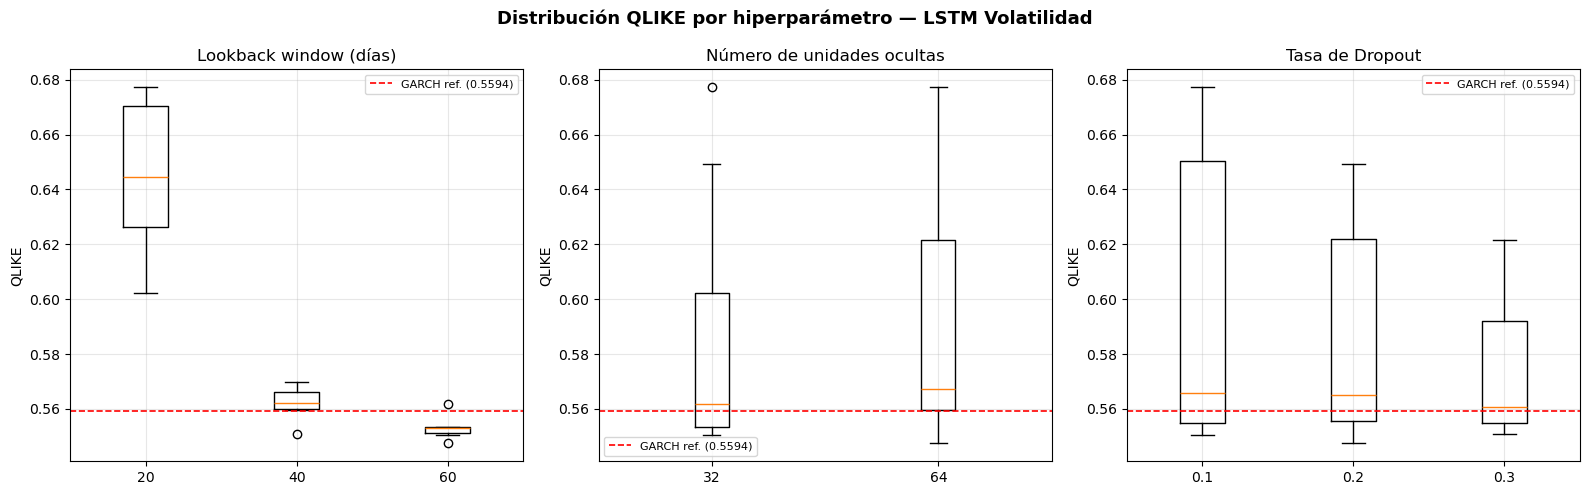

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# BOX-PLOT DE RESULTADOS — análogo al de retornos

import matplotlib.pyplot as plt

# Referencia GARCH para la línea horizontal
GARCH_REF_QLIKE = 0.559411

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, titulo in zip(
        axes,
        ["L", "units", "dropout"],
        ["Lookback window (días)",
         "Número de unidades ocultas",
         "Tasa de Dropout"]):
    grupos = [df_grid[df_grid[col] == v]["QLIKE_med"].values
              for v in sorted(df_grid[col].unique())]
    labels = sorted(df_grid[col].unique())
    ax.boxplot(grupos, labels=labels)
    ax.axhline(GARCH_REF_QLIKE, color="red", linestyle="--",
               linewidth=1.2, label=f"GARCH ref. ({GARCH_REF_QLIKE:.4f})")
    ax.set_title(titulo)
    ax.set_ylabel("QLIKE")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Distribución QLIKE por hiperparámetro — LSTM Volatilidad",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()